In [2]:
import pandas as pd
import numpy as np
from ofi_func import calc_ofi_features
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

# Explore the dataset

In [3]:
df = pd.read_csv('/content/first_25000_rows.csv')
df.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21T11:54:29.221064336Z,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21T11:54:29.223769812Z,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21T11:54:29.225030400Z,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21T11:54:29.712434212Z,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21T11:54:29.764673165Z,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


In [4]:
df[df.isna()].count() #data are pretty clean

,0
ts_recv,0
ts_event,0
rtype,0
publisher_id,0
instrument_id,0
...,...
bid_sz_09,0
ask_sz_09,0
bid_ct_09,0
ask_ct_09,0


In [5]:
df.columns

Index(['ts_recv', 'ts_event', 'rtype', 'publisher_id', 'instrument_id',
       'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta',
       'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00',
       'bid_ct_00', 'ask_ct_00', 'bid_px_01', 'ask_px_01', 'bid_sz_01',
       'ask_sz_01', 'bid_ct_01', 'ask_ct_01', 'bid_px_02', 'ask_px_02',
       'bid_sz_02', 'ask_sz_02', 'bid_ct_02', 'ask_ct_02', 'bid_px_03',
       'ask_px_03', 'bid_sz_03', 'ask_sz_03', 'bid_ct_03', 'ask_ct_03',
       'bid_px_04', 'ask_px_04', 'bid_sz_04', 'ask_sz_04', 'bid_ct_04',
       'ask_ct_04', 'bid_px_05', 'ask_px_05', 'bid_sz_05', 'ask_sz_05',
       'bid_ct_05', 'ask_ct_05', 'bid_px_06', 'ask_px_06', 'bid_sz_06',
       'ask_sz_06', 'bid_ct_06', 'ask_ct_06', 'bid_px_07', 'ask_px_07',
       'bid_sz_07', 'ask_sz_07', 'bid_ct_07', 'ask_ct_07', 'bid_px_08',
       'ask_px_08', 'bid_sz_08', 'ask_sz_08', 'bid_ct_08', 'ask_ct_08',
       'bid_px_09', 'ask_px_09', 'bid_sz_09', 'ask_sz_09', 'bi

In [6]:
# Sort the data using ts_event
df = df.sort_values(by='ts_event')

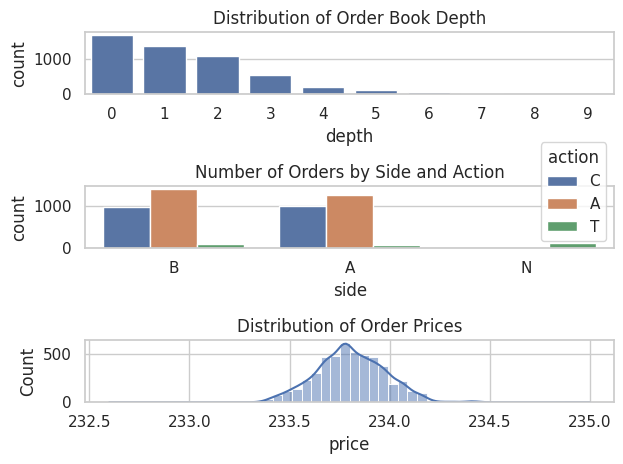

In [11]:
plt.subplot(3, 1, 1)
sns.countplot(data=df, x='depth')
plt.title('Distribution of Order Book Depth')

plt.subplot(3, 1, 2)
sns.countplot(data=df, x='side', hue='action')
plt.title('Number of Orders by Side and Action')

plt.subplot(3, 1, 3)
sns.histplot(data=df, x='price', bins=50, kde=True)
plt.title('Distribution of Order Prices')

plt.tight_layout()
plt.savefig('eda_summary.png')
plt.show()

# Construct Best-Level OFI, Muli-Level OFI, Integrated OFI

In [12]:
# Compute features
df = calc_ofi_features(df, levels=10, rolling_window=50)

In [13]:
df[['ts_event', 'ofi_best', 'ofi_multi', 'ofi_integrated']].head()

,ts_event,ofi_best,ofi_multi,ofi_integrated
0,2024-10-21T11:54:29.221064336Z,NaN,NaN,NaN
1,2024-10-21T11:54:29.223769812Z,2.0,2.000000,2.0
2,2024-10-21T11:54:29.225030400Z,3.0,3.000000,5.0
3,2024-10-21T11:54:29.712434212Z,0.0,66.666667,5.0
4,2024-10-21T11:54:29.764673165Z,0.0,-66.666667,5.0


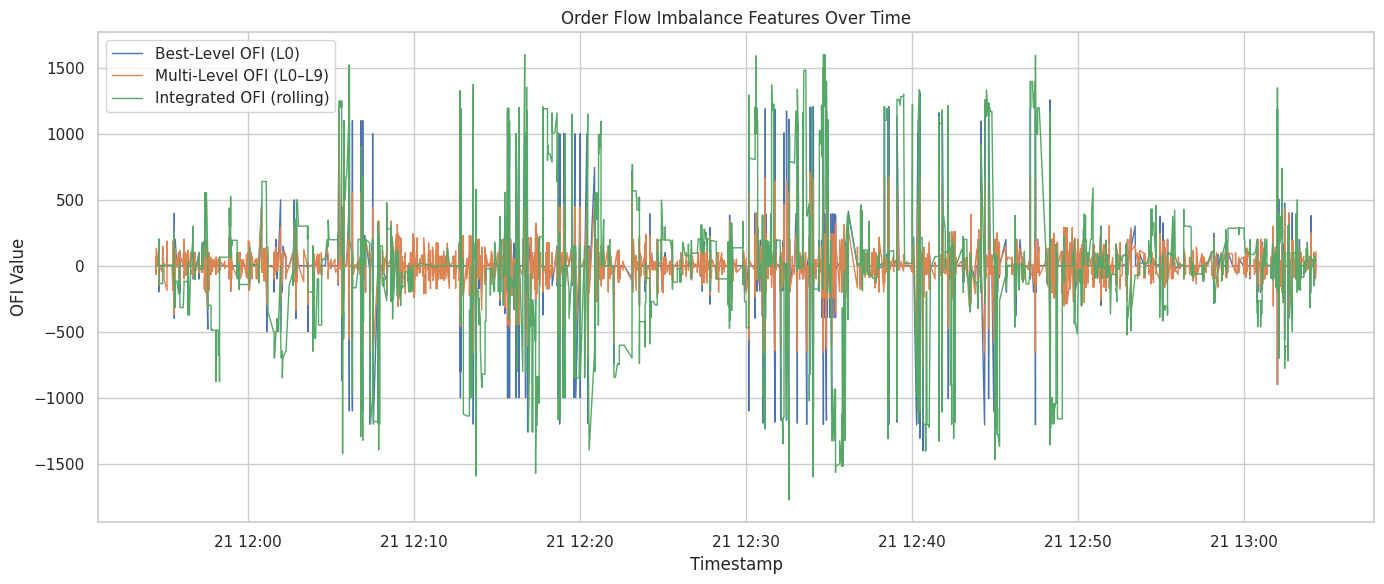

In [14]:
df['ts_event'] = pd.to_datetime(df['ts_event'])

df_plot = df.set_index('ts_event')

plt.figure(figsize=(14, 6))
plt.plot(df_plot['ofi_best'], label='Best-Level OFI (L0)', linewidth=1)
plt.plot(df_plot['ofi_multi'], label='Multi-Level OFI (L0–L9)', linewidth=1)
plt.plot(df_plot['ofi_integrated'], label='Integrated OFI (rolling)', linewidth=1)

plt.title('Order Flow Imbalance Features Over Time')
plt.xlabel('Timestamp')
plt.ylabel('OFI Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

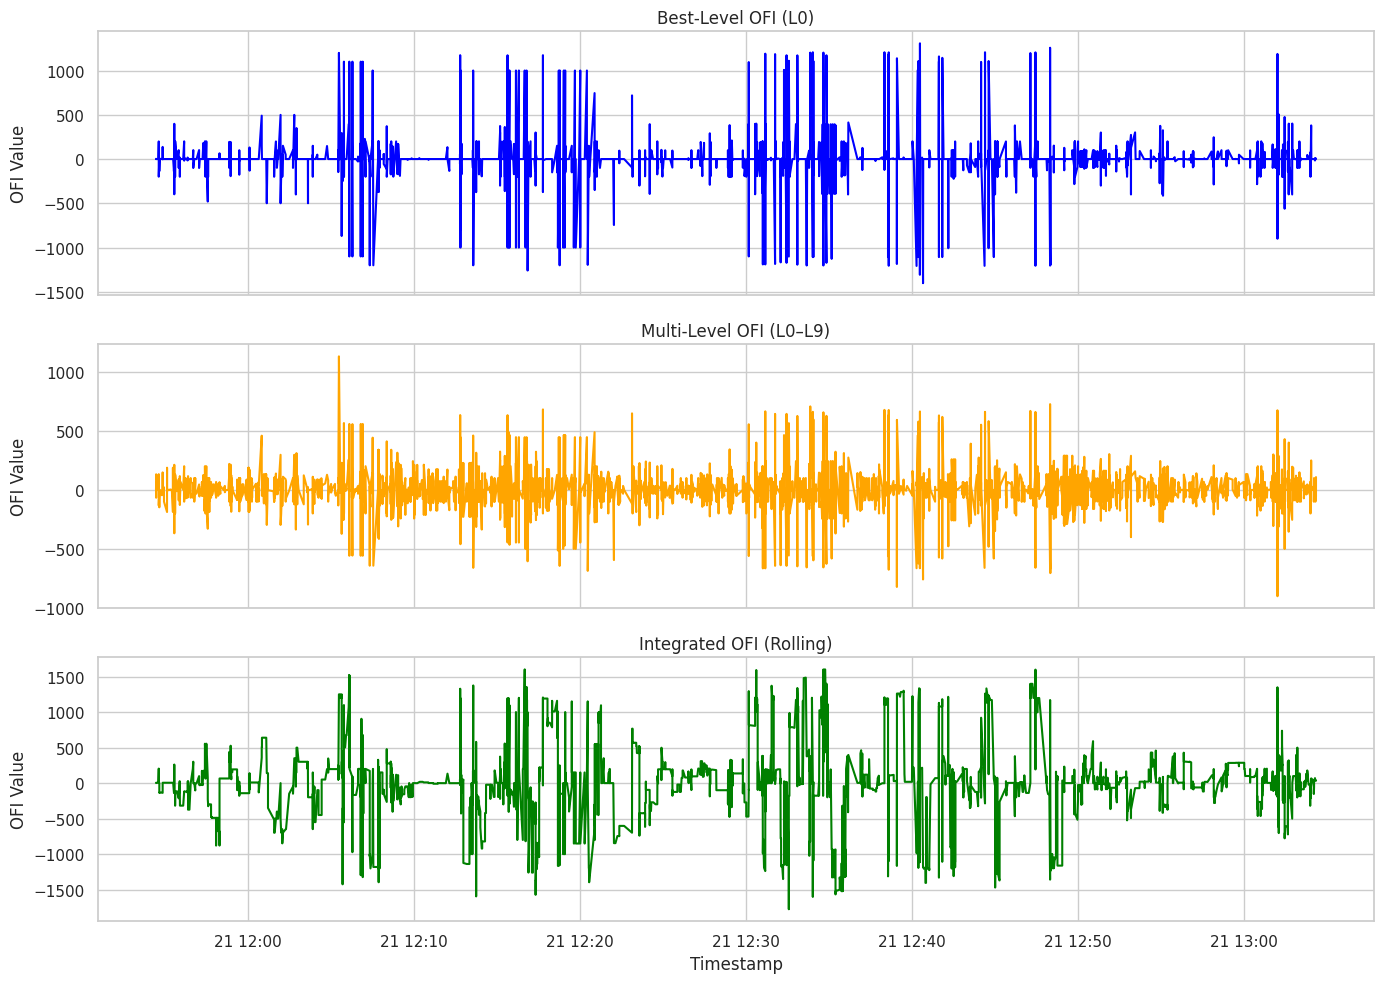

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axs[0].plot(df_plot['ofi_best'], color='blue')
axs[0].set_title('Best-Level OFI (L0)')
axs[0].set_ylabel('OFI Value')

axs[1].plot(df_plot['ofi_multi'], color='orange')
axs[1].set_title('Multi-Level OFI (L0–L9)')
axs[1].set_ylabel('OFI Value')

axs[2].plot(df_plot['ofi_integrated'], color='green')
axs[2].set_title('Integrated OFI (Rolling)')
axs[2].set_ylabel('OFI Value')
axs[2].set_xlabel('Timestamp')

plt.tight_layout()
plt.savefig('ofi_stacked_plot.png', dpi=300)
plt.show()


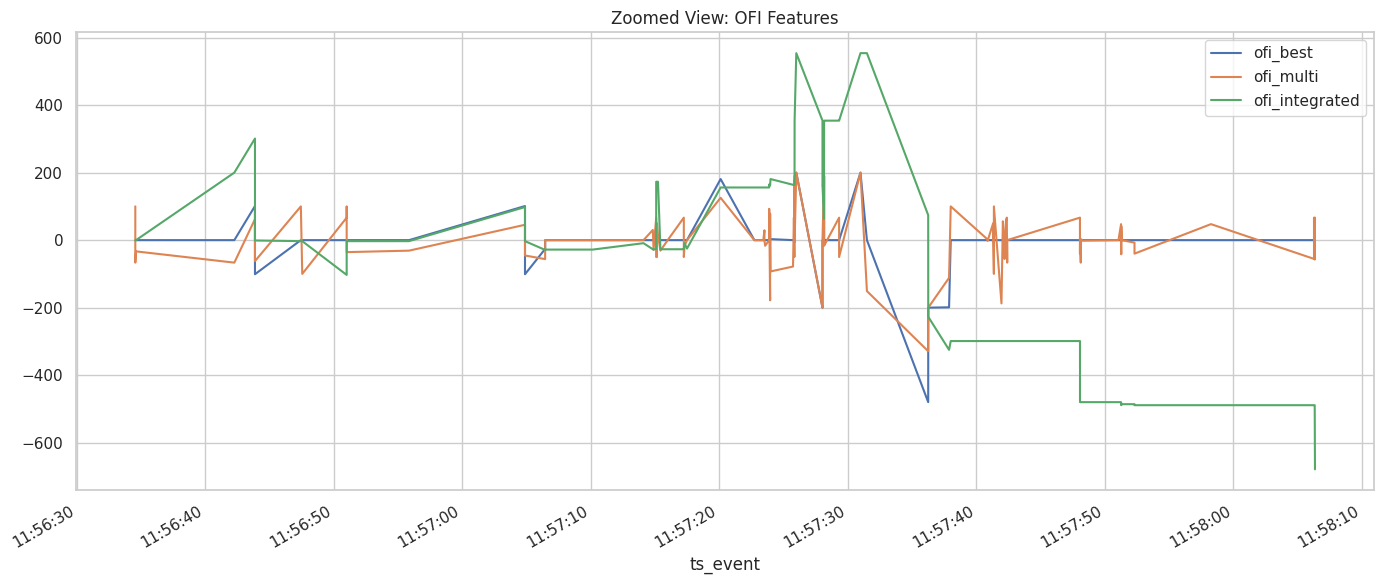

In [16]:
# Highlight a sharp market imbalance
subset = df_plot.iloc[100:200]  # Choose smaller slice
subset[['ofi_best', 'ofi_multi', 'ofi_integrated']].plot(figsize=(14, 6))
plt.title('Zoomed View: OFI Features')
plt.grid(True)
plt.tight_layout()
plt.savefig('ofi_zoomed_view.png', dpi=300)
plt.show()


# Cross-Asset OFI

In [ ]:
pivot_df = df.pivot_table(
    index='ts_event',
    columns='symbol',
    values='ofi_best',
    aggfunc='mean'
)

In [ ]:
pivot_df.head()

symbol,AAPL
ts_event,
2024-10-21 11:54:29.223769812+00:00,2.0
2024-10-21 11:54:29.225030400+00:00,3.0
2024-10-21 11:54:29.712434212+00:00,0.0
2024-10-21 11:54:29.764673165+00:00,0.0
2024-10-21 11:54:29.764685027+00:00,0.0


In [ ]:
df['symbol']

,symbol
0,AAPL
1,AAPL
2,AAPL
3,AAPL
4,AAPL
...,...
4995,AAPL
4996,AAPL
4997,AAPL
4998,AAPL


In [ ]:
df['symbol'].unique()


array(['AAPL'], dtype=object)

## Note

* We only have one ticker, APPL, which makes it not feasible to simulate cross-asset OFI
* For  illustration purpose, we would like to extend it to use 'fake' data// data we copied and set it to two different companies, to demonstrate how can you do this.

In [ ]:
# Create fake copies
df_msft = df.copy()
df_amzn = df.copy()

# Modify the symbol
df_msft['symbol'] = 'MSFT'
df_amzn['symbol'] = 'AMZN'

# Add noise to ofi_best
np.random.seed(42)
df_msft['ofi_best'] += np.random.normal(0, 0.5, size=len(df_msft))
df_amzn['ofi_best'] -= np.random.normal(0, 0.5, size=len(df_amzn))

# Combine into one dataset
df_extended = pd.concat([df, df_msft, df_amzn], ignore_index=True)
df_extended.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,d_bid_sz_06,d_ask_sz_06,d_bid_sz_07,d_ask_sz_07,d_bid_sz_08,d_ask_sz_08,d_bid_sz_09,d_ask_sz_09,ofi_multi,ofi_integrated
0,2024-10-21T11:54:29.221230963Z,2024-10-21 11:54:29.221064336+00:00,10,2,38,C,B,1,233.62,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-10-21T11:54:29.223936626Z,2024-10-21 11:54:29.223769812+00:00,10,2,38,A,B,0,233.67,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.0
2,2024-10-21T11:54:29.225196809Z,2024-10-21 11:54:29.225030400+00:00,10,2,38,A,B,0,233.67,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,5.0
3,2024-10-21T11:54:29.712600612Z,2024-10-21 11:54:29.712434212+00:00,10,2,38,A,B,2,233.52,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.666667,5.0
4,2024-10-21T11:54:29.764839221Z,2024-10-21 11:54:29.764673165+00:00,10,2,38,C,B,2,233.52,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-66.666667,5.0


In [ ]:
pivot_df = df_extended.pivot_table(
    index='ts_event',
    columns='symbol',
    values='ofi_best',
    aggfunc='mean'
)
pivot_df.head()

symbol,AAPL,AMZN,MSFT
ts_event,,,
2024-10-21 11:54:29.223769812+00:00,2.0,2.226707,1.930868
2024-10-21 11:54:29.225030400+00:00,3.0,3.897822,3.323844
2024-10-21 11:54:29.712434212+00:00,0.0,0.165045,0.761515
2024-10-21 11:54:29.764673165+00:00,0.0,-0.366415,-0.117077
2024-10-21 11:54:29.764685027+00:00,0.0,0.637116,-0.117068


In [ ]:
# Define beta weights for AAPL
weights = {'MSFT': 0.5, 'AMZN': 0.5}

# Compute weighted sum
pivot_df['cross_ofi_AAPL'] = sum(
    weights[sym] * pivot_df[sym] for sym in weights if sym in pivot_df.columns
)

In [ ]:
pivot_df.head()

symbol,AAPL,AMZN,MSFT,cross_ofi_AAPL
ts_event,,,,
2024-10-21 11:54:29.223769812+00:00,2.0,2.226707,1.930868,2.078787
2024-10-21 11:54:29.225030400+00:00,3.0,3.897822,3.323844,3.610833
2024-10-21 11:54:29.712434212+00:00,0.0,0.165045,0.761515,0.463280
2024-10-21 11:54:29.764673165+00:00,0.0,-0.366415,-0.117077,-0.241746
2024-10-21 11:54:29.764685027+00:00,0.0,0.637116,-0.117068,0.260024
